# 00 — Executive summary
### Olist Brazilian E-Commerce · `retail-platform-analytics`

A one-screen rollup of the platform, distilling the four deep-dive notebooks into the handful of
findings a stakeholder needs. Every number is computed live from the dbt marts on Snowflake.

| Read this for the headline | Go deeper in |
|---|---|
| Growth, scale, and where revenue comes from | [`01` exploratory analysis](01_exploratory_analysis.ipynb) |
| Why customers are satisfied (or not) | [`02` delivery & satisfaction](02_delivery_and_satisfaction.ipynb) |
| Who the customers are | [`03` customer segmentation (RFM)](03_customer_segmentation_rfm.ipynb) |
| Where margin leaks | [`04` category & freight economics](04_category_and_freight_economics.ipynb) |

*Dataset: ~100k orders, Sep 2016 – Oct 2018. Trend charts use the reliable window **Jan 2017 – Aug
2018** (the edge months are data ramp-in/cutoff, not real demand).*

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

## 1. The platform at a glance

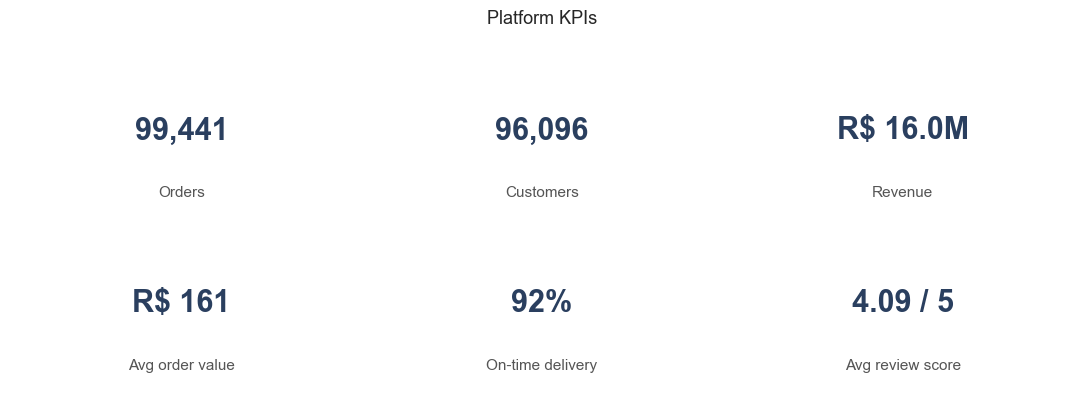

In [2]:
kpi = q('''
    select count(*) as orders,
           count(distinct customer_id) as customers,
           sum(total_payment_value) as revenue,
           avg(total_payment_value) as aov,
           avg(iff(status = 'delivered', 1, 0)) * 100 as delivered_pct,
           avg(review_score) as avg_review
    from dev_marts.fct_orders
''').iloc[0]
on_time = q("select avg(iff(is_delivered_on_time,1,0))*100 p from dev_marts.fct_orders where status='delivered' and is_delivered_on_time is not null").iloc[0, 0]

cards = [
    ("Orders", f"{kpi['orders']:,.0f}"),
    ("Customers", f"{kpi['customers']:,.0f}"),
    ("Revenue", f"R$ {kpi['revenue']/1e6:,.1f}M"),
    ("Avg order value", f"R$ {kpi['aov']:,.0f}"),
    ("On-time delivery", f"{on_time:.0f}%"),
    ("Avg review score", f"{kpi['avg_review']:.2f} / 5"),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 4))
for ax, (label, val) in zip(axes.ravel(), cards):
    ax.axis("off")
    ax.text(0.5, 0.62, val, ha="center", va="center", fontsize=22, fontweight="bold", color="#2A3F5F")
    ax.text(0.5, 0.22, label, ha="center", va="center", fontsize=11, color="#555")
fig.suptitle("Platform KPIs", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**~100k orders and R$16M in revenue** from a two-year run, 97% delivered, at a healthy ~4.1★
average. A solid, functioning marketplace — the questions below are about *quality of growth*, not
survival.

## 2. Growth story

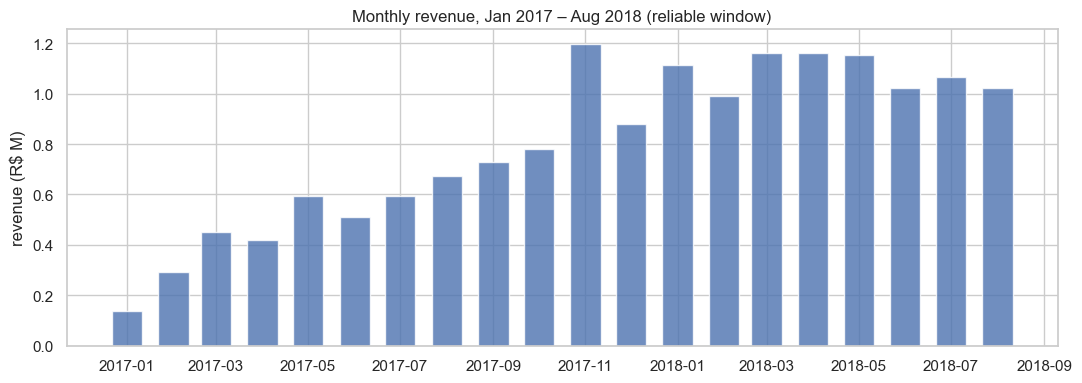

In [3]:
monthly = q('''
    select date_trunc('month', purchased_at)::date as month,
           count(*) as orders, sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    where purchased_at >= '2017-01-01' and purchased_at < '2018-09-01'
    group by 1 order by 1
''')
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly["month"], monthly["revenue"] / 1e6, width=20, color="#4C72B0", alpha=0.8)
bf = monthly.loc[monthly["month"] == pd.Timestamp("2017-11-01")]
if len(bf):
    ax.annotate("Black Friday\n(Nov 2017)", xy=(bf["month"].iloc[0], bf["revenue"].iloc[0] / 1e6),
                xytext=(bf["month"].iloc[0], bf["revenue"].iloc[0] / 1e6 + 0.35),
                ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", color="#C44E52"))
ax.set_title("Monthly revenue, Jan 2017 – Aug 2018 (reliable window)")
ax.set_ylabel("revenue (R$ M)")
plt.tight_layout(); plt.show()

**Strong, decelerating growth.** Monthly volume roughly quadrupled across 2017 and settled at a
~R$1M/month run-rate in 2018, with a clear **Black Friday** spike (Nov 2017). Quarter-on-quarter growth
cooled from +76% early to low single digits as the base matured — a maturing business, not a stalling
one. *(Detail: `01`.)*

## 3. The satisfaction lever — deliver on time

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_49127/1037325201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev, x="label", y="avg_score", ax=ax, palette=["#C44E52", "#55A868"])


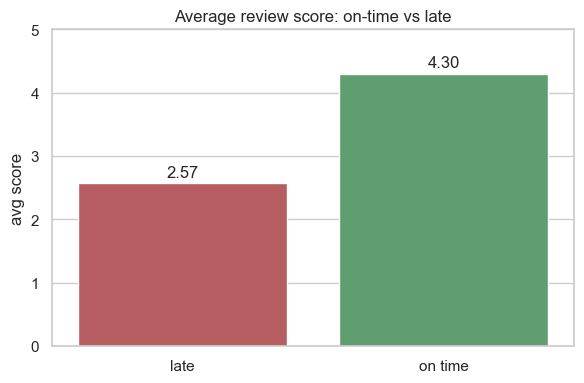

In [4]:
rev = q('''
    select is_delivered_on_time, count(*) as orders, avg(review_score) as avg_score
    from dev_marts.fct_orders
    where status='delivered' and review_score is not null and is_delivered_on_time is not null
    group by 1 order by 1
''')
rev["label"] = rev["is_delivered_on_time"].map({True: "on time", False: "late"})
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=rev, x="label", y="avg_score", ax=ax, palette=["#C44E52", "#55A868"])
ax.set_ylim(0, 5); ax.set_title("Average review score: on-time vs late"); ax.set_xlabel(""); ax.set_ylabel("avg score")
for i, r in rev.iterrows():
    ax.text(i, r["avg_score"] + 0.1, f"{r['avg_score']:.2f}", ha="center")
plt.tight_layout(); plt.show()

**The single biggest driver of satisfaction is on-time delivery.** On-time orders average
**4.30★**; late orders collapse to **2.57★** — a 1.7-point swing that holds after controlling for
distance, weight, and category. Delivery reliability, not price or product, is what customers rate.
*(Detail: `02`.)*

## 4. Who the customers are — acquisition, not loyalty

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_49127/2970725370.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rev_share.values, y=rev_share.index, ax=ax, palette="crest")


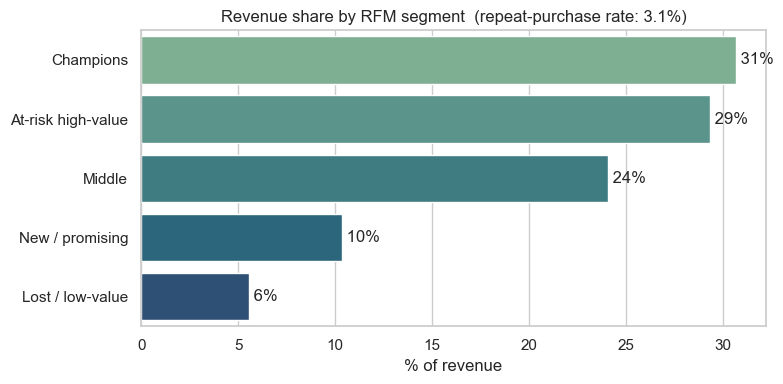

In [5]:
cust = q('''
    select total_orders, total_spend,
           datediff('day', last_order_at, (select max(last_order_at) from dev_marts.mart_customer_summary)) as recency
    from dev_marts.mart_customer_summary
''')
for c in cust.columns:
    cust[c] = pd.to_numeric(cust[c], errors="coerce")
repeat_pct = 100 * (cust["total_orders"] >= 2).mean()
cust["r"] = pd.qcut(cust["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
cust["m"] = pd.qcut(cust["total_spend"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
def seg(r, m):
    if r >= 4 and m >= 4: return "Champions"
    if r >= 4 and m <= 3: return "New / promising"
    if r <= 2 and m >= 4: return "At-risk high-value"
    if r <= 2 and m <= 2: return "Lost / low-value"
    return "Middle"
cust["segment"] = [seg(r, m) for r, m in zip(cust["r"], cust["m"])]
order = ["Champions", "At-risk high-value", "Middle", "New / promising", "Lost / low-value"]
rev_share = (cust.groupby("segment")["total_spend"].sum() / cust["total_spend"].sum() * 100).reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=rev_share.values, y=rev_share.index, ax=ax, palette="crest")
ax.set_title(f"Revenue share by RFM segment  (repeat-purchase rate: {repeat_pct:.1f}%)")
ax.set_xlabel("% of revenue"); ax.set_ylabel("")
for i, v in enumerate(rev_share.values):
    ax.text(v, i, f" {v:.0f}%", va="center")
plt.tight_layout(); plt.show()

**Olist is acquisition-led: only ~3% of customers ever buy twice.** Value is concentrated —
*Champions* and *At-risk high-value* together hold ~60% of revenue. With no repeat behaviour to build
on, the growth levers are **acquisition and reactivation** (winning back the At-risk high-value pocket),
not loyalty tiering. *(Detail: `03`.)*

## 5. Where margin leaks — freight drag by category

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_49127/1846183567.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="category_name", x="freight_pct", ax=ax, palette=colors)


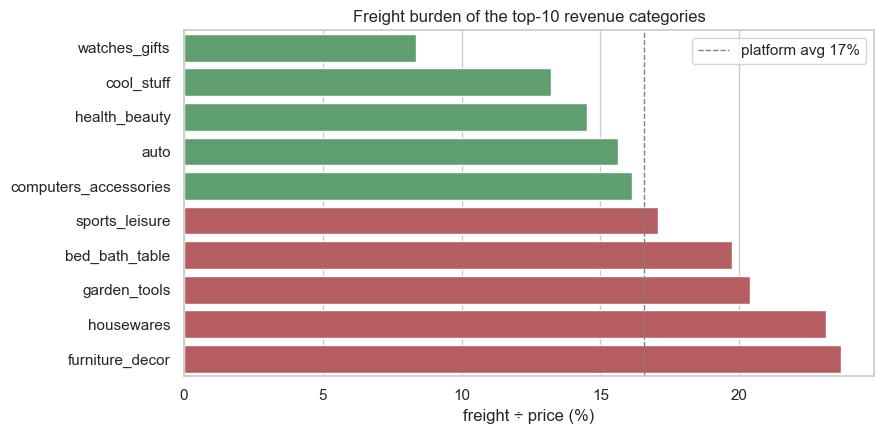

In [6]:
cat = q('''
    select oi.category_name, count(*) as items, sum(oi.total_item_value) as revenue,
           100.0 * sum(oi.freight_value) / sum(oi.price) as freight_pct
    from dev_marts.fct_order_items oi
    where oi.category_name is not null
    group by 1 having count(*) >= 300
''')
overall = q("select 100.0*sum(freight_value)/sum(price) p from dev_marts.fct_order_items").iloc[0, 0]
top = cat.sort_values("revenue", ascending=False).head(10).sort_values("freight_pct")
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#C44E52" if p > overall else "#55A868" for p in top["freight_pct"]]
sns.barplot(data=top, y="category_name", x="freight_pct", ax=ax, palette=colors)
ax.axvline(overall, color="grey", ls="--", lw=1, label=f"platform avg {overall:.0f}%")
ax.set_title("Freight burden of the top-10 revenue categories"); ax.set_xlabel("freight ÷ price (%)"); ax.set_ylabel("")
ax.legend()
plt.tight_layout(); plt.show()

**Freight eats ~17% of sale value on average — but unevenly.** Bulky home categories
(`bed_bath_table`, `furniture_decor`, `housewares`) and cheap electronics run 20–29%, squeezing margin;
high-ticket `watches_gifts` and `health_beauty` stay margin-safe (~8–15%). Two fixes: **logistics** for
the bulky lines, **pricing/basket rules** for the cheap-and-light ones. *(Detail: `04`.)*

## 6. Where the business is — geographic concentration

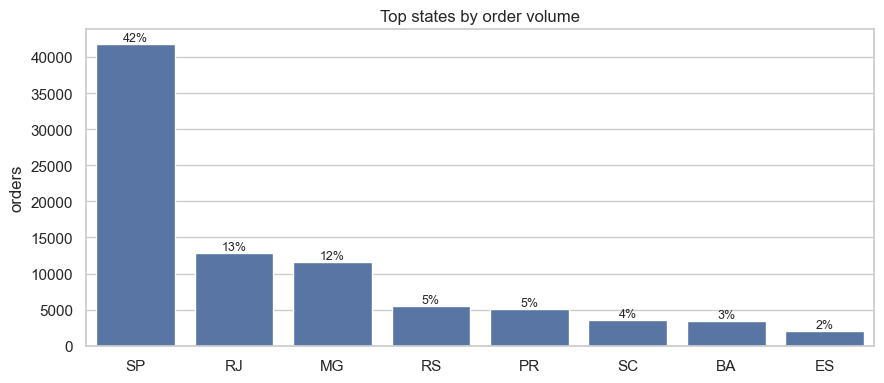

In [7]:
geo = q('''
    select delivery_state as state, count(*) as orders
    from dev_marts.fct_orders where delivery_state is not null
    group by 1 order by 2 desc limit 8
''')
geo["share"] = 100 * geo["orders"] / q("select count(*) n from dev_marts.fct_orders").iloc[0, 0]
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=geo, x="state", y="orders", ax=ax, color="#4C72B0")
ax.set_title("Top states by order volume"); ax.set_xlabel(""); ax.set_ylabel("orders")
for i, r in geo.iterrows():
    ax.text(i, r["orders"], f"{r['share']:.0f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

**São Paulo alone is ~42% of orders**, and the Southeast dominates. National averages are
effectively SP averages, and delivery reliability drops on the long routes to the North/Northeast — a
service-equity gap that also drags satisfaction there. *(Detail: `02`.)*

## Executive takeaways

1. **Healthy but maturing growth** — ~R$16M over two years, growth decelerating as the base matures.
   Keep the acquisition engine running.
2. **Protect on-time delivery above all** — it's the dominant satisfaction lever (4.30★ vs 2.57★).
   Guard it especially on long routes to the underserved North/Northeast.
3. **Compete on acquisition & reactivation, not loyalty** — ~97% of customers buy once; target the
   *At-risk high-value* segment (~30% of revenue) with win-back.
4. **Plug the freight margin leak** — logistics fixes for bulky categories, pricing/basket rules for
   cheap-and-light ones; protect the margin-safe revenue drivers.

*Built on the dbt + Snowflake marts in this repo; see notebooks `01`–`04` for the full analysis behind
each point.*